In [1]:
import pandas as pd

df_model = pd.read_csv('../data/fraud_model_ready.csv')
df_model.shape

(1296675, 35)

In [2]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Train fraud rate:", y_train.mean())
print("Val fraud rate:", y_val.mean())

Train shape: (1037340, 34)
Val shape: (259335, 34)
Train fraud rate: 0.00578884454470087
Val fraud rate: 0.005787880540613492


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [4]:
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred)
print(cm)

[[246490  11344]
 [   213   1288]]


In [6]:
print(classification_report(y_val, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.999     0.956     0.977    257834
           1      0.102     0.858     0.182      1501

    accuracy                          0.955    259335
   macro avg      0.551     0.907     0.580    259335
weighted avg      0.994     0.955     0.972    259335



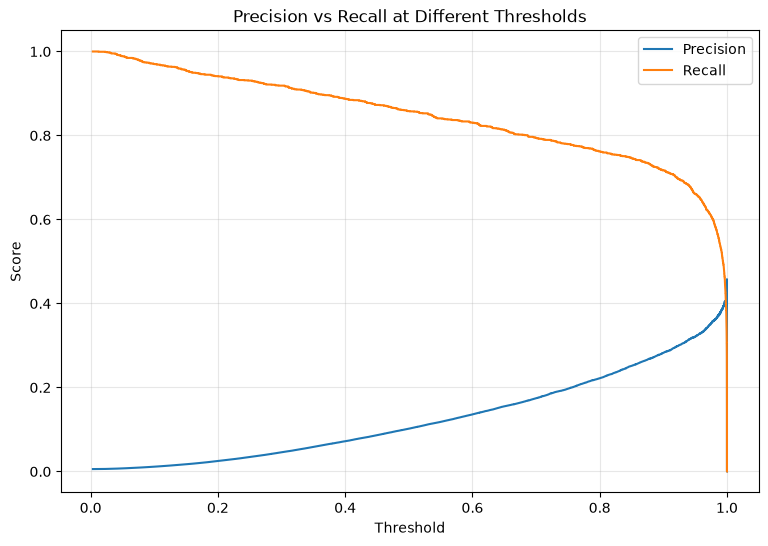

In [7]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.figure(figsize=(9, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
import numpy as np

target_recall = 0.75
valid_indices = np.where(recalls[:-1] >= target_recall)[0]
best_index = valid_indices[np.argmax(precisions[:-1][valid_indices])]

best_threshold = thresholds[best_index]
print(f"Threshold: {best_threshold:.3f}")
print(f"Precision at this threshold: {precisions[best_index]:.3f}")
print(f"Recall at this threshold: {recalls[best_index]:.3f}")

Threshold: 0.841
Precision at this threshold: 0.246
Recall at this threshold: 0.750


In [9]:
y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)
cm_tuned = confusion_matrix(y_val, y_pred_tuned)
print(cm_tuned)

[[254381   3453]
 [   375   1126]]


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [11]:
y_pred_rf = rf_model.predict(X_val)
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]

cm_rf = confusion_matrix(y_val, y_pred_rf)
print(cm_rf)
print(classification_report(y_val, y_pred_rf, digits=3))

[[257763     71]
 [   180   1321]]
              precision    recall  f1-score   support

           0      0.999     1.000     1.000    257834
           1      0.949     0.880     0.913      1501

    accuracy                          0.999    259335
   macro avg      0.974     0.940     0.956    259335
weighted avg      0.999     0.999     0.999    259335



In [12]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

                    feature  importance
0                       amt    0.246232
15        cc_avg_amt_roll10    0.196225
13            amt_vs_cc_avg    0.143755
9                  is_night    0.076361
17     cc_median_amt_roll10    0.069432
16     amt_vs_cc_avg_roll10    0.048451
7                      hour    0.039920
18  amt_vs_cc_median_roll10    0.034086
33            merchant_freq    0.019940
14      mins_since_last_txn    0.019804
12               cc_avg_amt    0.014868
11       cc_txn_total_count    0.014758
21   category_gas_transport    0.013791
23     category_grocery_pos    0.007777
10                      age    0.005634


In [13]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

cm_xgb = confusion_matrix(y_val, y_pred_xgb)
print(cm_xgb)
print(classification_report(y_val, y_pred_xgb, digits=3))

[[257587    247]
 [    45   1456]]
              precision    recall  f1-score   support

           0      1.000     0.999     0.999    257834
           1      0.855     0.970     0.909      1501

    accuracy                          0.999    259335
   macro avg      0.927     0.985     0.954    259335
weighted avg      0.999     0.999     0.999    259335



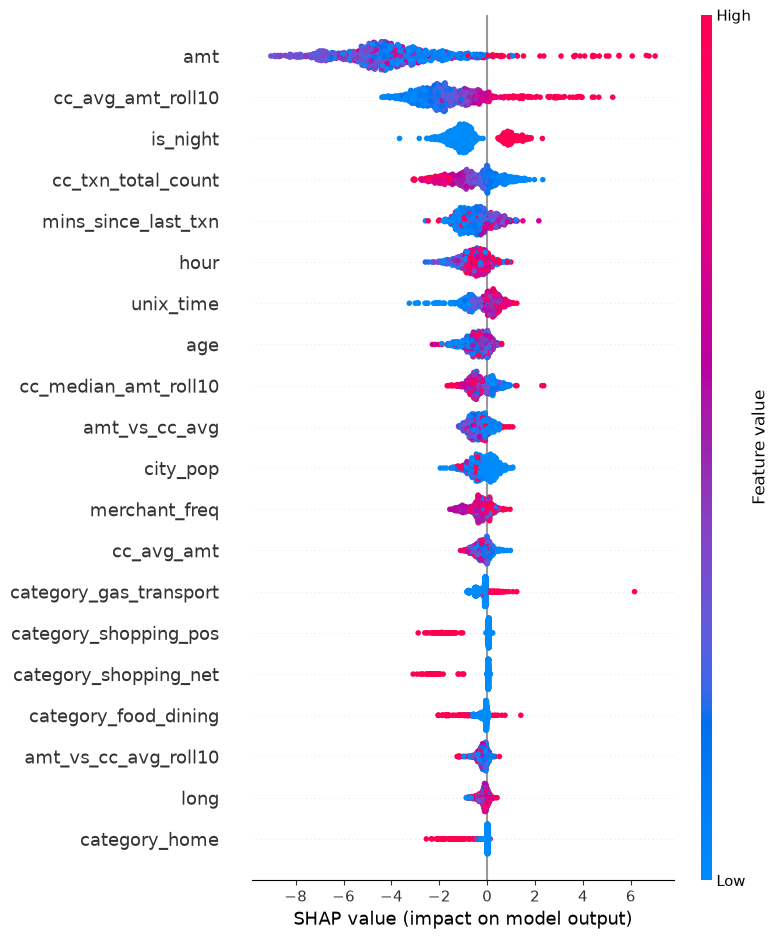

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val.iloc[:1000])

shap.summary_plot(shap_values, X_val.iloc[:1000])

In [16]:
extra_drop = ['unix_time', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop']
df_model = df_model.drop(columns=extra_drop)
df_model.shape

(1296675, 29)

In [17]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

cm_xgb = confusion_matrix(y_val, y_pred_xgb)
print(cm_xgb)
print(classification_report(y_val, y_pred_xgb, digits=3))

[[257587    247]
 [    45   1456]]
              precision    recall  f1-score   support

           0      1.000     0.999     0.999    257834
           1      0.855     0.970     0.909      1501

    accuracy                          0.999    259335
   macro avg      0.927     0.985     0.954    259335
weighted avg      0.999     0.999     0.999    259335



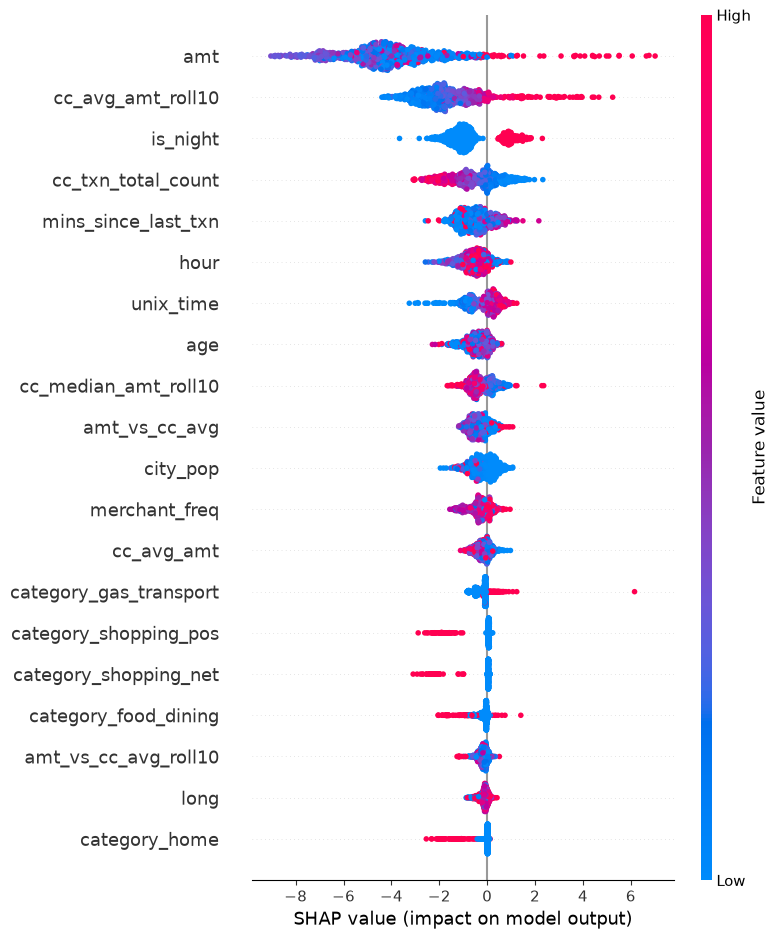

In [19]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val.iloc[:1000])
shap.summary_plot(shap_values, X_val.iloc[:1000])

In [20]:
print(df_model.shape)
print('unix_time' in X_val.columns)
print('city_pop' in X_val.columns)

(1296675, 29)
True
True


In [21]:
# 1. Drop the leftover raw columns from df_model
extra_drop = ['unix_time', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop']
df_model = df_model.drop(columns=[c for c in extra_drop if c in df_model.columns])
print(df_model.shape)  # expect 29 columns

(1296675, 29)


In [22]:
# 2. Rebuild X/y and re-split
X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Retrain XGBoost fresh on the cleaned columns
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 4. Confirm the fix
print('unix_time' in X_val.columns)   # should be False
print('city_pop' in X_val.columns)    # should be False

False
False


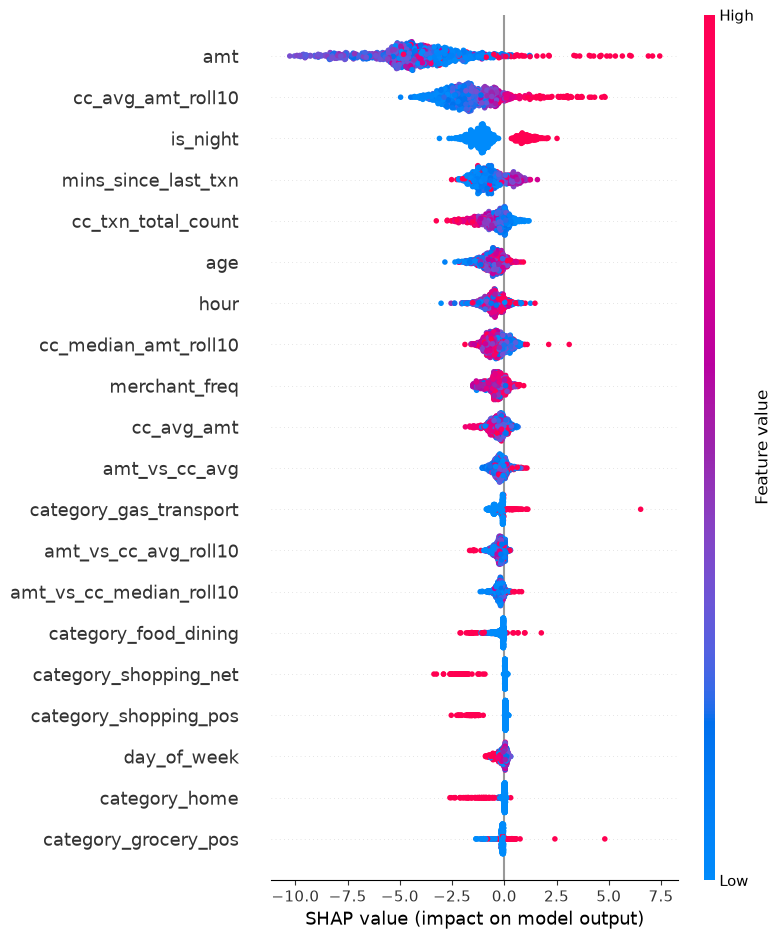

In [23]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val.iloc[:1000])
shap.summary_plot(shap_values, X_val.iloc[:1000])

In [24]:
def engineer_features(raw_df):
    df = raw_df.copy()
    
    # Basic cleanup
    df = df.drop(columns=['Unnamed: 0'])
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    # Time features
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['is_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)
    
    # Age
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    
    # Velocity features
    df = df.sort_values(['cc_num', 'trans_date_trans_time'])
    df['cc_txn_total_count'] = df.groupby('cc_num').cumcount() + 1
    
    df['cc_avg_amt'] = df.groupby('cc_num')['amt'].transform(
        lambda x: x.expanding().mean().shift(1))
    df['amt_vs_cc_avg'] = df['amt'] / df['cc_avg_amt']
    
    df['cc_avg_amt_roll10'] = df.groupby('cc_num')['amt'].transform(
        lambda x: x.rolling(window=10, min_periods=1).mean().shift(1))
    df['amt_vs_cc_avg_roll10'] = df['amt'] / df['cc_avg_amt_roll10']
    
    df['cc_median_amt_roll10'] = df.groupby('cc_num')['amt'].transform(
        lambda x: x.rolling(window=10, min_periods=1).median().shift(1))
    df['amt_vs_cc_median_roll10'] = df['amt'] / df['cc_median_amt_roll10']
    
    df['mins_since_last_txn'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 60
    
    # Encoding
    df['gender_encoded'] = df['gender'].map({'M': 1, 'F': 0})
    df = pd.get_dummies(df, columns=['category'], prefix='category', drop_first=True)
    
    merchant_counts = df['merchant'].value_counts()
    df['merchant_freq'] = df['merchant'].map(merchant_counts)
    
    # Fill NaNs
    overall_avg_amt = df['amt'].mean()
    for col in ['cc_avg_amt', 'cc_avg_amt_roll10', 'cc_median_amt_roll10']:
        df[col] = df[col].fillna(overall_avg_amt)
    for col in ['amt_vs_cc_avg', 'amt_vs_cc_avg_roll10', 'amt_vs_cc_median_roll10']:
        df[col] = df[col].fillna(1)
    df['mins_since_last_txn'] = df['mins_since_last_txn'].fillna(df['mins_since_last_txn'].max())
    
    # Drop everything raw/redundant/leftover
    drop_cols = ['street', 'first', 'last', 'zip', 'trans_num', 'city', 'state', 
                 'job', 'merchant', 'gender', 'dob', 'trans_date_trans_time', 'cc_num',
                 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop']
    df = df.drop(columns=drop_cols)
    
    return df

In [25]:
df_test_raw = pd.read_csv('../data/fraudTest.csv')
df_test_model = engineer_features(df_test_raw)

X_test = df_test_model.drop(columns=['is_fraud'])
y_test = df_test_model['is_fraud']

X_test = X_test[X_train.columns]  # ensure exact same column order as training

X_test.shape

(555719, 28)

In [26]:
y_pred_test = xgb_model.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)
print(classification_report(y_test, y_pred_test, digits=3))

[[552693    881]
 [   176   1969]]
              precision    recall  f1-score   support

           0      1.000     0.998     0.999    553574
           1      0.691     0.918     0.788      2145

    accuracy                          0.998    555719
   macro avg      0.845     0.958     0.894    555719
weighted avg      0.998     0.998     0.998    555719



In [27]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_model, '../models/xgb_fraud_model.pkl')
joblib.dump(list(X_train.columns), '../models/model_columns.pkl')

['../models/model_columns.pkl']

In [28]:
predictions_df = pd.DataFrame({
    'predicted_fraud': y_pred_test,
    'fraud_probability': xgb_model.predict_proba(X_test)[:, 1]
}, index=X_test.index)

engineered_extra = df_test_model.loc[X_test.index, ['hour', 'is_night', 'age', 'amt_vs_cc_median_roll10']]

dashboard_export = df_test_raw.join(predictions_df).join(engineered_extra)

dashboard_export.to_csv('../data/fraud_dashboard_export.csv', index=False)
dashboard_export.shape

(555719, 29)